In [1]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    EsmConfig,
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [3]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile

# Load CovFit model

In [4]:
TOK_DIR = "./covfit_stuff/Tokenizer"
CONF_DIR = "./covfit_stuff/Config"
TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt"
FOLD_ID = 0
N_TARGETS = 1565
MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt"

In [5]:
# MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
# FOLD_IDS_TO_USE = [0]
# TARGET_FOLD_ID = 0
# OUTPUT_PREFIX = "inference_results"

model_name = "facebook/esm2_t33_650M_UR50D"
device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [6]:
def get_model(
    TOK_DIR = "./covfit_stuff/Tokenizer",
    CONF_DIR = "./covfit_stuff/Config",
    TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt",
    FOLD_ID = 0,
    N_TARGETS = 1565,
    MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt",
    device=device
):
    esm_config = EsmConfig.from_pretrained(CONF_DIR)
    model = EsmForRegression(esm_config, N_TARGETS).to(device)

    lora_config = LoraConfig(
        task_type="SEQ_CLS",
        r=8,
        lora_alpha=16,
        target_modules=["key", "query", "value","dense"],
        lora_dropout=0.05,
        bias="lora_only",
        modules_to_save=["regressor"]
    )
    esm_fine_tuned = get_peft_model(model, lora_config)
    state_dict = torch.load(MODEL_PATH, map_location=device)
    
    # keys_to_remove = []
    # for key in state_dict.keys():
    #     if 'contact_head' in key:
    #         keys_to_remove.append(key)
    
    # for key in keys_to_remove:
    #     del state_dict[key]

    wrong_keys = [key for key in state_dict.keys() if key not in esm_fine_tuned.state_dict().keys()]
    key_list = list(state_dict.keys())
    for key in key_list:
        if key in wrong_keys:
            correct_key = key.rsplit('.',1)[0]+'.base_layer.'+key.rsplit('.',1)[1]
            state_dict[correct_key] = state_dict.pop(key)

    del state_dict["base_model.model.esm.embeddings.position_embeddings.base_layer.weight"]
    
    esm_fine_tuned.load_state_dict(state_dict)
    esm_fine_tuned = esm_fine_tuned.merge_and_unload()
    esm_fine_tuned.eval()
    esm_fine_tuned.esm.embeddings.token_dropout = False

    return esm_fine_tuned

In [7]:
esm_fine_tuned = get_model()

In [8]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [9]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name
REPO_ID = esm_config.model_name
original_task_id_infos = torch.load("./covfit_stuff/task_id_dict.pt", map_location=device)

In [10]:
tokenizer_config = {}
special_tokens_map_file = "./covfit_stuff/Tokenizer/special_tokens_map.json"
tokenizer_config["vocab_file"] = "./covfit_stuff/Tokenizer/vocab.txt"
tokenizer_config["model_max_length"] = CONTEXT_LEN

with open("./covfit_stuff/Tokenizer/special_tokens_map.json", "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [11]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

In [12]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [13]:
# clean up memory
torch.cuda.empty_cache()

# Load Data

In [14]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [15]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [16]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [17]:
"""
uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]
    
    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences 

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences 
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4404
torch.Size([4404, 1024])


In [18]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [19]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [20]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [21]:
def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_seq)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

In [22]:
logit_id = original_task_id_infos["fitness_USA"]

# Curating new fitness with low-mutation dataset

# L455F mutation

In [23]:
N = 455
np.random.seed(30)
num_L_muts = len([x for x in all_uniq_seqs if x[N-1] == "L"])
# orig_seq_idx = np.random.permutation(np.arange(num_L_muts))[:200] 
orig_seq_idx = np.random.permutation(np.arange(num_L_muts))[:100]

orig_idx = list(np.array([x for x in all_uniq_seqs if x[N-1] == "L"])[orig_seq_idx])
new_idx = [x[:N-1] + "F" + x[N:] for x in orig_idx]

mask_ablate_idx = [x[:N-1] + "<mask>" + x[N:] for x in orig_idx]

In [24]:
# # L455F mutation 
# N = 455

# orig_seq_idx = [i for i,x in enumerate(all_uniq_seqs) if x[N-1] == "L"]

# orig_idx = [x for x in all_uniq_seqs if x[N-1] == "L"][:100]
# new_idx = [x[:N-1] + "F" + x[N:] for x in orig_idx]

# N = 456
# orig_idx = [x for x in all_uniq_seqs if x[N-1] == "F"][:100]
# new_idx = [x[:N-1] + "L" + x[N:] for x in orig_idx][:100]

orig_toks = tokenizer(orig_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
new_toks = tokenizer(new_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
ablate_toks = tokenizer(mask_ablate_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)

In [25]:
orig_output = get_logit_hooked(hooked_esm(orig_toks), logit_id)
torch.cuda.empty_cache()
new_output = get_logit_hooked(hooked_esm(new_toks), logit_id)
torch.cuda.empty_cache()
ablate_output = get_logit_hooked(hooked_esm(ablate_toks), logit_id)
torch.cuda.empty_cache()

In [26]:
diffs = (new_output - orig_output).cpu().numpy()

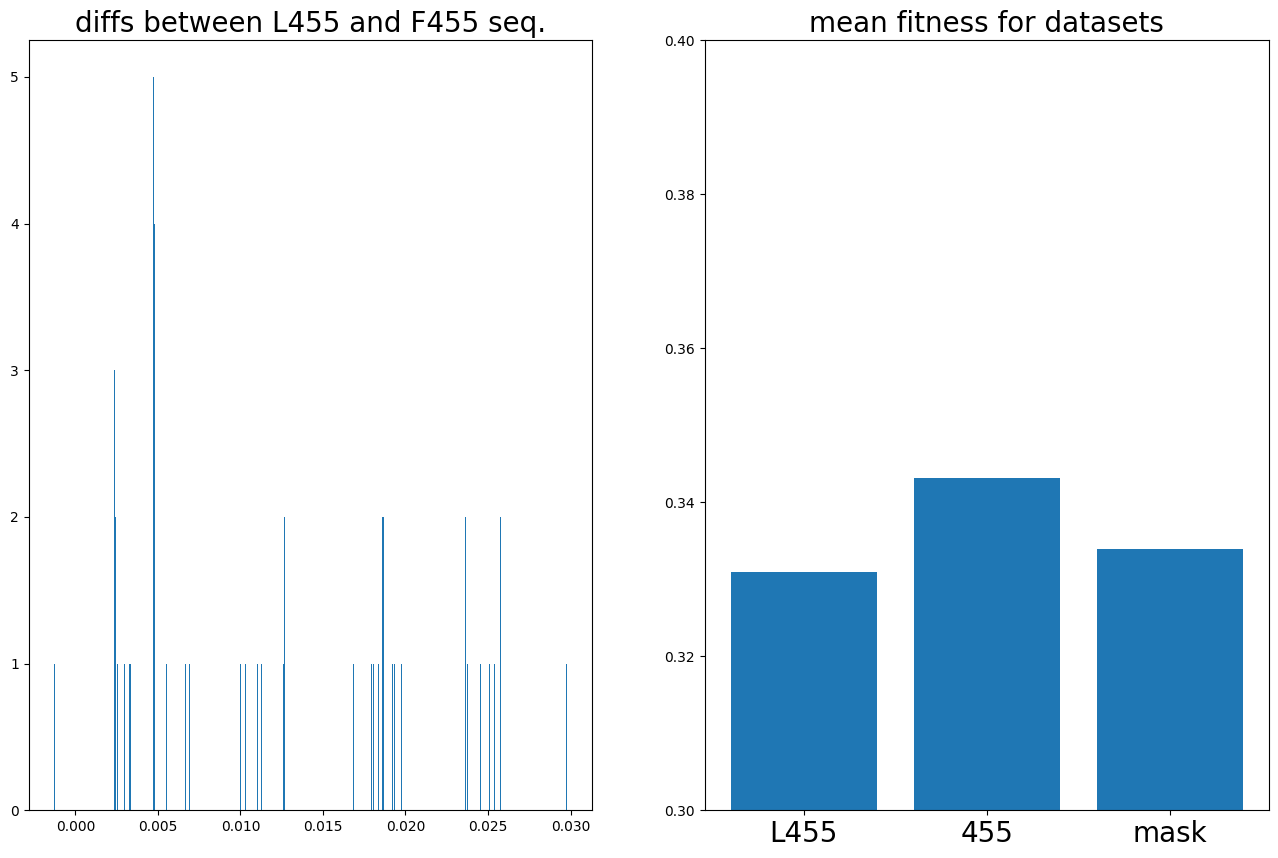

In [27]:
fig, ax = plt.subplots(1,2,figsize=(16,10))
ax[0].hist(diffs, bins=1000)
ax[0].set_title("diffs between L455 and F455 seq.", fontsize=20)
ax[1].bar([0,1,2], [s.mean().cpu().numpy() for s in [orig_output, new_output, ablate_output]])
ax[1].set_title("mean fitness for datasets", fontsize=20)
ax[1].set_xticks([0,1,2])
ax[1].set_xticklabels(["L455", "455", "mask"], fontsize=20)
ax[1].set_ylim([0.3,0.4])
# ax.set_xlim([0,0.04])
plt.show()

In [28]:
# del orig_output
# del new_output
# torch.cuda.empty_cache()

# Re-running patching experiments

In [29]:
clean_toks = new_toks
corr_toks = orig_toks

In [30]:
fit_mean_diff_high_low = new_output.mean(dim=0).cpu().numpy() - orig_output.mean(dim=0).cpu().numpy() 

In [31]:
def get_recovery_metrics(clean_out_pred, corr_out_pred, new_output, orig_output):
    clean_perf_recover = 1 - ((new_output - clean_out_pred).abs() / new_output).mean()
    corr_perf_recover = 1 - ((orig_output - corr_out_pred).abs() / orig_output).mean()

    fit_mean_diff_high_low = new_output.mean(dim=0).cpu().numpy() - orig_output.mean(dim=0).cpu().numpy() 
    # fit_diff_recover = 1 - np.square((clean_out_pred - corr_out_pred).mean().cpu().numpy() -  fit_mean_diff_high_low)/ np.square(fit_mean_diff_high_low)
    fit_diff_recover = 1 - np.abs((clean_out_pred - corr_out_pred).mean().cpu().numpy() -  fit_mean_diff_high_low)/ np.abs(fit_mean_diff_high_low)
    new_diff = (clean_out_pred - corr_out_pred).mean().cpu().numpy()

    return clean_perf_recover, corr_perf_recover, fit_diff_recover, new_diff

# Evaluating Circuit

## Completeness
### Let $\begin{cases} F(\cdot) \text{ denote model logit diff. when only including certain nodes (and mean-ablating others).} \\ C\text{ := circuit} \\ M \text{ := model}  \end{cases}$
### Here, I examine $|F(M) - F(C)|$

In [32]:
# HOOK FUNCTIONS for mean ablation
def abs_path_patch_head_input(
    orig_head_vector: Float[Tensor, "batch pos n_head d_head"],
    hook: HookPoint,
    new_comp: Float[Tensor, "pos n_head d_head"], # changed_head_vector at head_idx
    head_idx: Int[Tensor, "n_heads"]
):
    orig_head_vector[:,:,head_idx,:] = new_comp[:,head_idx,:]
    return orig_head_vector


def abs_path_patch_mlp_input(
    orig_mlp_vector: Float[Tensor, "batch pos d_model"],
    hook: HookPoint,
    new_comp: Float[Tensor, "pos d_model"], # changed_mlp_vector
):
    orig_mlp_vector[...] = new_comp[...]
    return orig_mlp_vector

# ACTUAL FUNCTION
def run_mean_ablate(
    model,
    toks: Int[Tensor, "batch seq_len"], 
    ablation_cache,
    head_range: Bool[Tensor, "n_layer n_head"], # True if head should be mean-ablated otherwise False
    mlp_range: Bool[Tensor, "n_layer"], # True if mlp should be mean-ablated otherwise False
    verbose=False
):
    model.reset_hooks()
    for layer in range(model.cfg.n_layers):
        attn_name = f"blocks.{layer}.attn.hook_z"
        mlp_name = f"blocks.{layer}.hook_mlp_out"

        if torch.any(head_range[layer]):
            excl_heads = torch.argwhere(head_range[layer]).squeeze()
            model.add_hook(
                attn_name,
                functools.partial(abs_path_patch_head_input, new_comp=ablation_cache[attn_name].mean(dim=0), head_idx=excl_heads),
                dir="fwd"
            )
            if verbose:
                print(f"excluding heads: {layer}-{excl_heads}")

        if mlp_range[layer]:
            model.add_hook(
                mlp_name,
                functools.partial(abs_path_patch_mlp_input, new_comp=ablation_cache[mlp_name].mean(dim=0)),
                dir="fwd"
            )
            if verbose:
                print(f"excluding mlp: {layer}\n")

    ablated_output = model(toks) # [batch pos d_model]
    ablated_logits = get_logit_hooked(ablated_output, logit_id)
    torch.cuda.empty_cache()
    model.reset_hooks()
    
    return ablated_logits
    

In [94]:
head_range = torch.full((hooked_esm.cfg.n_layers, hooked_esm.cfg.n_heads), fill_value=True) 
head_range[0,:] = False

head_range[1,15] = False
head_range[2,[4,17]] = False
head_range[12,18] = False
head_range[13,[5,9]] = False
head_range[14,6] = False

head_range[32][[5,8,13]] = False
head_range[31][[1,2,3,7,8,9,12,13,14,15,17]] = False

mlp_range = torch.full((hooked_esm.cfg.n_layers, 1), fill_value=True).squeeze()
mlp_range[[0,2,8,11,14,15,16,*list(range(18,26,1)),*list(range(26,32,1))]] = False
# mlp_range[[0,11,24,26,27,28,29,30,31]] = False

In [95]:
def run_mean_ablate_batched(
    model,
    batch_dim,
    orig_toks, # L455 seqs
    new_toks, # F455 seqs
    ablate_toks, # ablation dset seqs (<mask>455)
    head_range: Bool[Tensor, "n_layer n_head"], # True if head should be mean-ablated otherwise False
    mlp_range: Bool[Tensor, "n_layer"], # True if mlp should be mean-ablated otherwise False
    verbose = lambda i: True if i == 0 else False
):
    attn_names = [utils.get_act_name("z", layer) for layer in range(hooked_esm.cfg.n_layers)]
    mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm.cfg.n_layers)]

    l_ablate_logits = torch.empty(clean_toks.shape[0]).to(device)
    f_ablate_logits = torch.empty(clean_toks.shape[0]).to(device)
    
    for i in range(0,clean_toks.shape[0],batch_dim):
        batch_L = orig_toks[i:(i+batch_dim)]
        batch_F = new_toks[i:(i+batch_dim)]
        batch_ablate = ablate_toks[i:(i+batch_dim)]
        
        _, ablate_cache = hooked_esm.run_with_cache(batch_ablate, names_filter=[*attn_names, *mlp_names])
    
        l_ablate_logits[i:(i+batch_dim)] = run_mean_ablate(hooked_esm, batch_L, ablate_cache, head_range=head_range, mlp_range=mlp_range, verbose=verbose(i))
        torch.cuda.empty_cache()
        f_ablate_logits[i:(i+batch_dim)] = run_mean_ablate(hooked_esm, batch_F, ablate_cache, head_range=head_range, mlp_range=mlp_range)
        torch.cuda.empty_cache()
    
        del _
        del ablate_cache
        torch.cuda.empty_cache()

    return l_ablate_logits, f_ablate_logits

In [96]:
l_ablate_logits, f_ablate_logits = run_mean_ablate_batched(
    hooked_esm,
    batch_dim=80,
    orig_toks=orig_toks,
    new_toks=new_toks,
    ablate_toks=ablate_toks,
    head_range=head_range,
    mlp_range=mlp_range
)

excluding heads: 1-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 17, 18,
        19])
excluding mlp: 1

excluding heads: 2-tensor([ 0,  1,  2,  3,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 18, 19])
excluding heads: 3-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
excluding mlp: 3

excluding heads: 4-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
excluding mlp: 4

excluding heads: 5-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
excluding mlp: 5

excluding heads: 6-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
excluding mlp: 6

excluding heads: 7-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
excluding mlp: 7

excluding heads: 8-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
 

In [97]:
t1, t2, t3, new_diff = get_recovery_metrics(f_ablate_logits, l_ablate_logits, new_output=new_output, orig_output=orig_output)
t1 = t1.cpu().numpy()
t2 = t2.cpu().numpy()

In [98]:
for (n,lab) in zip(["clean fit recovery", "corr. fit recovery", "fit. diff. recovery", "new diff", "actual diff"], [t1, t2, t3, new_diff, fit_mean_diff_high_low]):
    print("%-30s:\t\t%.5f"%(n,lab))

clean fit recovery            :		0.79865
corr. fit recovery            :		0.79636
fit. diff. recovery           :		0.78513
new diff                      :		0.00960
actual diff                   :		0.01223


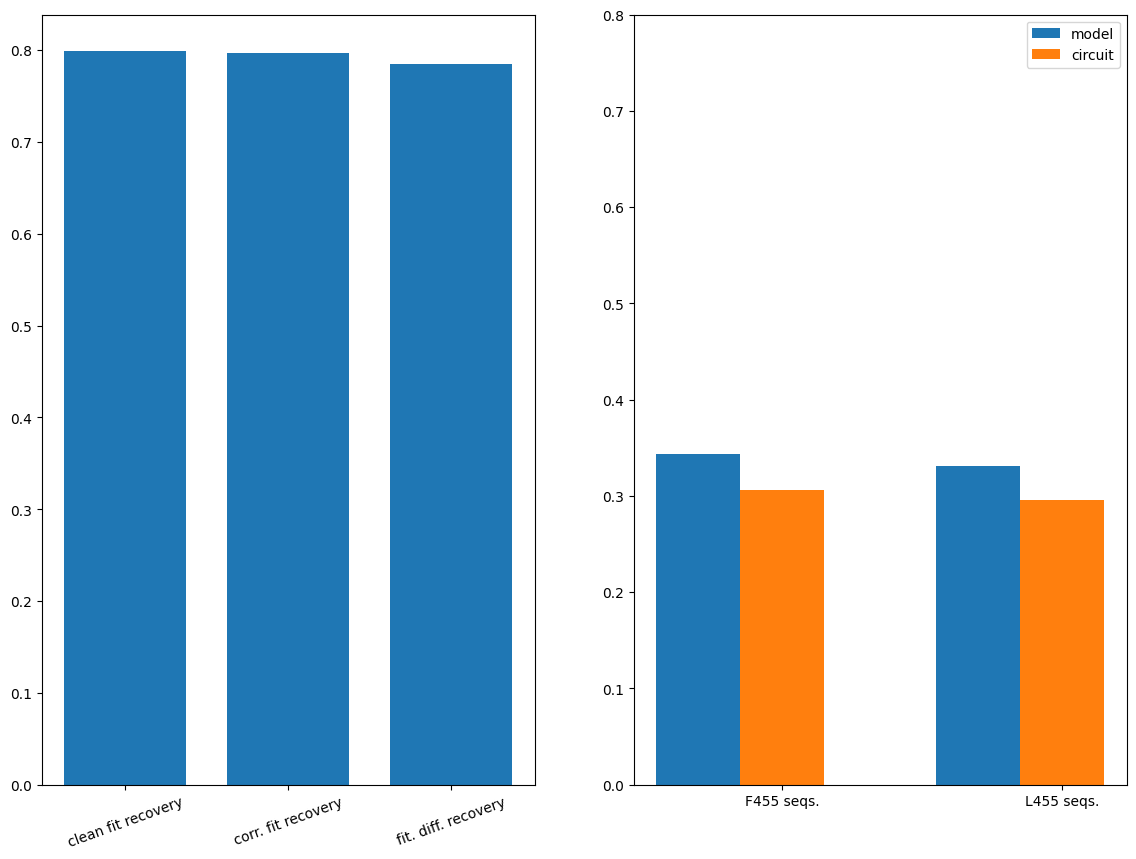

In [105]:
fig, ax = plt.subplots(1,2,figsize=(14,10))
ax[0].bar([i*0.4 for i in range(3)], [t1,t2,t3], width=0.3)
ax[0].set_xticks([i*0.4 for i in range(3)])
ax[0].set_xticklabels(["clean fit recovery", "corr. fit recovery", "fit. diff. recovery"], rotation=20)
ax[1].bar(list(range(2)), [new_output.mean().cpu().numpy(), orig_output.mean().cpu().numpy()],width=0.3, label="model")
ax[1].bar([i+0.3 for i in range(2)], [f_ablate_logits.mean().cpu().numpy(), l_ablate_logits.mean().cpu().numpy()], width=0.3, label="circuit")
ax[1].legend()
ax[1].set_ylim([0,0.8])
ax[1].set_xticks([0.3, 1.3])
ax[1].set_xticklabels(["F455 seqs.", "L455 seqs."])
plt.show()

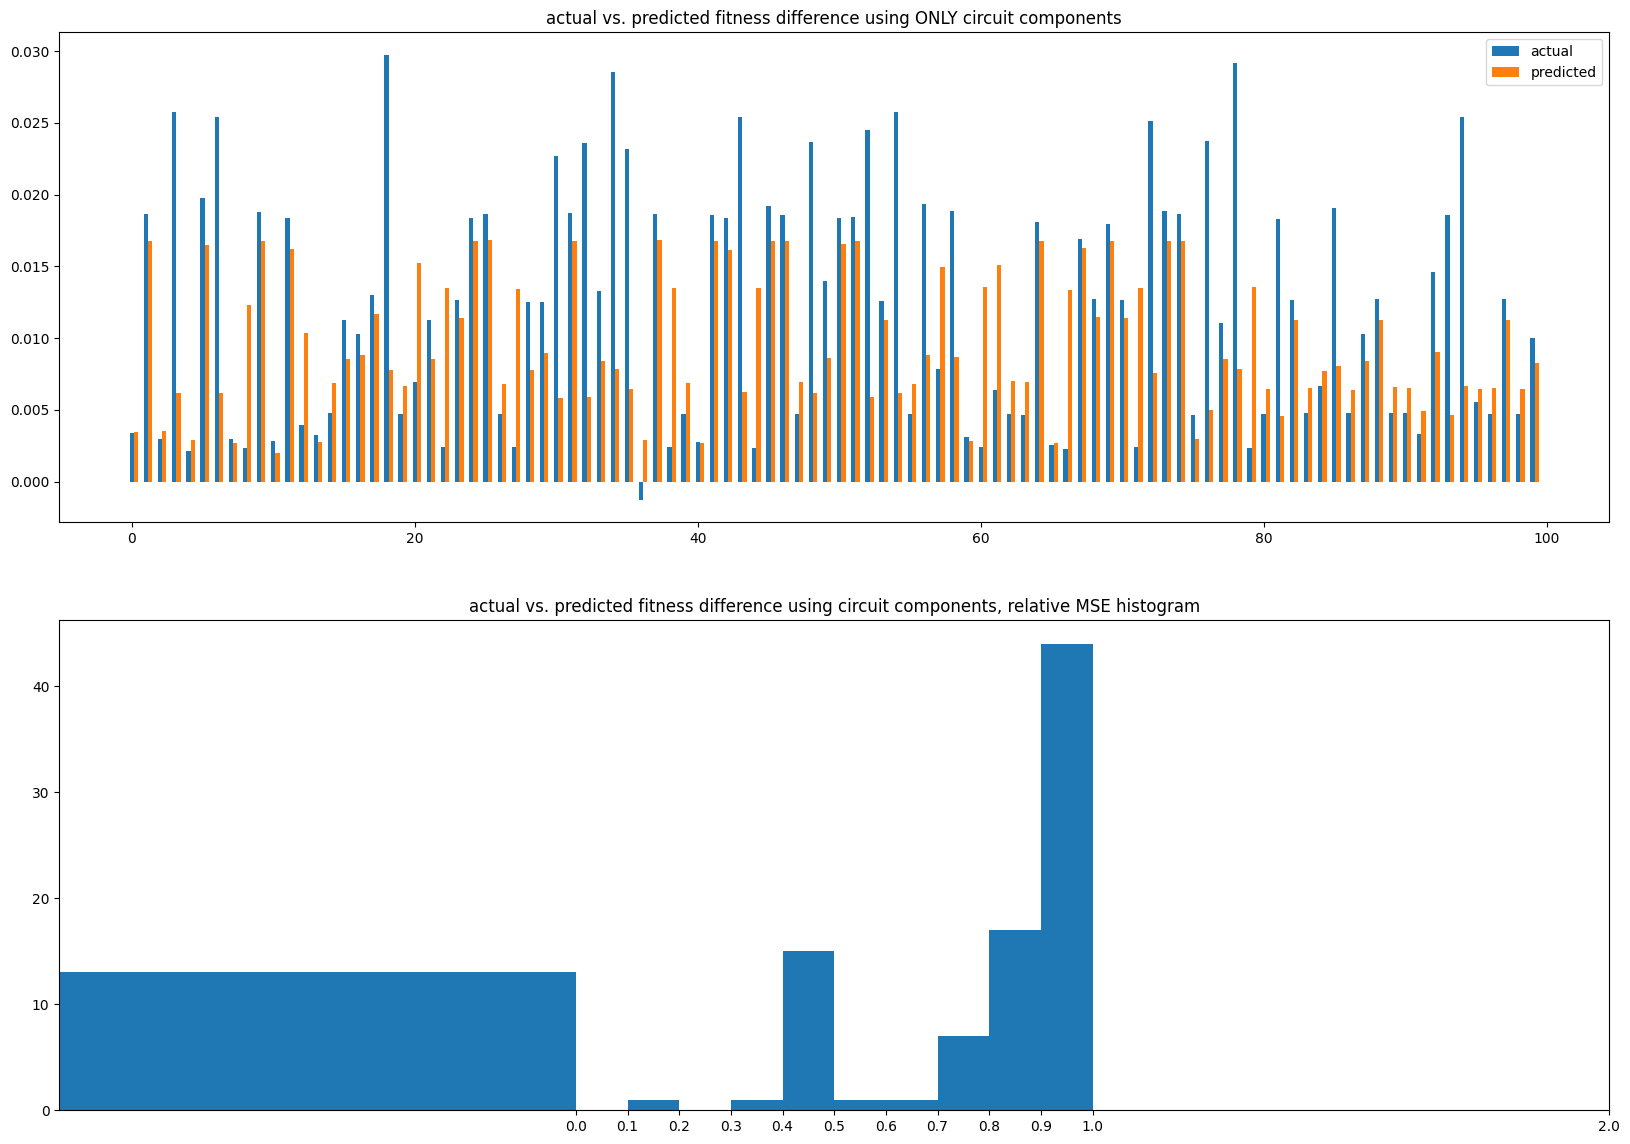

In [100]:
num_data = f_ablate_logits.shape[0]
predicted_diff = (f_ablate_logits - l_ablate_logits).cpu().numpy()
real_diff = (new_output - orig_output).cpu().numpy()

diff_recover_pred = 1 - np.square(predicted_diff -  real_diff) / np.square(real_diff)

fig, ax = plt.subplots(2,1,figsize=(20,14))
ax[0].bar(list(range(num_data)), real_diff,width=0.3, label="actual")
ax[0].bar([i+0.3 for i in range(num_data)], predicted_diff,width=0.3, label="predicted")
ax[0].set_title("actual vs. predicted fitness difference using ONLY circuit components")
ax[0].legend()
# ax[1].hist(diff_recover_pred[np.abs(diff_recover_pred) < 100], width=0.3, bins=200)
ax[1].set_title("actual vs. predicted fitness difference using circuit components, relative MSE histogram")
hist_bins = [-100, *[i*0.1 for i in range(11)], 2]
ax[1].hist(diff_recover_pred, bins=hist_bins)
ax[1].set_xlim([-1,1])
ax[1].set_xticks(hist_bins[1:])
# ax[1].set_ylim([-4,4])
plt.show()

# Evaluating Circuit

## Faithfulness
### Let $\begin{cases} F(\cdot) \text{ denote model logit diff. when only including certain nodes (and mean-ablating others).} \\ C\text{ := circuit} \\ M \text{ := model}  \end{cases}$
### Then $\forall K\subset C$, I plot $|F(M\textbackslash K) - F(C\textbackslash K)|$

In [40]:
# get heads, mlp that are NOT mean-ablated
circ_head_range = torch.logical_not(head_range)
circ_mlp_range = torch.logical_not(mlp_range)

In [41]:
true_diffs = []
circ_diffs = []
batch_dim = 100

In [42]:
for i in range(100):
    if i % 10 == 0:
        print()
    print(".",end="")

    if i == 0:
        verbose = lambda j: True if j == 0 else False
    else:
        verbose = lambda j: False

    # find random K_head subset C_head
    rand_head_range = torch.bernoulli(torch.full(size=(hooked_esm.cfg.n_layers, hooked_esm.cfg.n_heads), fill_value=0.5)) == 1
    rand_head_range = torch.logical_and(circ_head_range, rand_head_range)
    
    # new index for circuit and model
    new_circ_head_range = head_range.clone()
    new_circ_head_range[rand_head_range] = True # circuit heads ablate K_head
    
    new_model_head_range = torch.full(size=(hooked_esm.cfg.n_layers, hooked_esm.cfg.n_heads), fill_value=False)
    new_model_head_range[rand_head_range] = True # model heads ablate K_head


    # find random K_mlp subset C_mlp
    rand_mlp_range = torch.bernoulli(torch.full(size=(hooked_esm.cfg.n_layers, 1), fill_value=0.5)).squeeze() == 1
    rand_mlp_range = torch.logical_and(rand_mlp_range, circ_mlp_range)

    # new index for circuit and model
    new_circ_mlp_range = mlp_range.clone()
    new_circ_mlp_range[rand_mlp_range] = True # circuit heads ablate K_mlp
    
    new_model_mlp_range = torch.full(size=(hooked_esm.cfg.n_layers, 1), fill_value=False).squeeze()
    new_model_mlp_range[rand_mlp_range] = True # circuit heads ablate K_mlp


    # get logit diffs
    circ_l_ablate_logits, circ_f_ablate_logits = run_mean_ablate_batched(
        hooked_esm,
        batch_dim=batch_dim,
        orig_toks=orig_toks,
        new_toks=new_toks,
        ablate_toks=ablate_toks,
        head_range=new_circ_head_range,
        mlp_range=new_circ_mlp_range,
        verbose=verbose
    )

    
    model_l_ablate_logits, model_f_ablate_logits = run_mean_ablate_batched(
        hooked_esm,
        batch_dim=batch_dim,
        orig_toks=orig_toks,
        new_toks=new_toks,
        ablate_toks=ablate_toks,
        head_range=new_model_head_range,
        mlp_range=new_model_mlp_range,
        verbose=verbose
    )

    circ_diffs.append((circ_f_ablate_logits - circ_l_ablate_logits).mean())
    true_diffs.append((model_f_ablate_logits - model_l_ablate_logits).mean())
    


.excluding heads: 0-tensor([ 2,  4,  8,  9, 10, 13, 15, 16, 19])
excluding heads: 1-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
excluding mlp: 1

excluding heads: 2-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 18,
        19])
excluding heads: 3-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
excluding mlp: 3

excluding heads: 4-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
excluding mlp: 4

excluding heads: 5-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
excluding mlp: 5

excluding heads: 6-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
excluding mlp: 6

excluding heads: 7-tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
excluding mlp: 7

excluding heads: 8

# Notable subsets

In [ ]:
# new index for circuit and model
    new_circ_head_range = head_range.clone()
    new_circ_head_range[rand_head_range] = True # circuit heads ablate K_head
    
    new_model_head_range = torch.full(size=(hooked_esm.cfg.n_layers, hooked_esm.cfg.n_heads), fill_value=False)
    new_model_head_range[rand_head_range] = True # model heads ablate K_head


    # find random K_mlp subset C_mlp
    rand_mlp_range = torch.bernoulli(torch.full(size=(hooked_esm.cfg.n_layers, 1), fill_value=0.5)).squeeze() == 1
    rand_mlp_range = torch.logical_and(rand_mlp_range, circ_mlp_range)

    # new index for circuit and model
    new_circ_mlp_range = mlp_range.clone()
    new_circ_mlp_range[rand_mlp_range] = True # circuit heads ablate K_mlp
    
    new_model_mlp_range = torch.full(size=(hooked_esm.cfg.n_layers, 1), fill_value=False).squeeze()
    new_model_mlp_range[rand_mlp_range] = True # circuit heads ablate K_mlp

In [66]:
reg_model_head_range = torch.full(size=(hooked_esm.cfg.n_layers, hooked_esm.cfg.n_heads), fill_value=False)
reg_model_mlp_range = torch.full(size=(hooked_esm.cfg.n_layers, 1), fill_value=False).squeeze()

# CLS mover heads - ablate 32.5, 32.8, 32.13
cls_circ_head_range = head_range.clone()
cls_circ_head_range[32][[5,8,13]] = True

cls_model_head_range = reg_model_head_range.clone()
cls_model_head_range[32][[5,8,13]] = True
cls_mask_idxs = [(cls_circ_head_range, mlp_range, cls_model_head_range, reg_model_mlp_range)]

# aa455 heads - ablate 31.[1,2,3,7,8,9,12,13,14,15,17]
aa455_circ_head_range = head_range.clone()
aa455_circ_head_range[32][[1,2,3,7,8,9,12,13,14,15,17]] = True

aa455_model_head_range = reg_model_head_range.clone()
aa455_model_head_range[32][[1,2,3,7,8,9,12,13,14,15,17]] = True
aa455_mask_idxs = [(aa455_circ_head_range, mlp_range, aa455_model_head_range, reg_model_mlp_range)]

# indiv circ MLP ablation
mlp_to_ablate = torch.argwhere(torch.logical_not(mlp_range)).squeeze()
circ_indiv_mlp = [mlp_range.clone() for _ in mlp_to_ablate]
for i,s in enumerate(mlp_to_ablate):
    circ_indiv_mlp[i][s] = True

model_indiv_mlp = [reg_model_mlp_range.clone() for _ in mlp_to_ablate]
for i,s in enumerate(mlp_to_ablate):
    model_indiv_mlp[i][s] = True
indiv_mlp_idxs = [(head_range, circ_indiv_mlp[i], reg_model_head_range, model_indiv_mlp[i]) for i in range(mlp_to_ablate.shape[0])]

In [68]:
cls_mover_completeness = []
aa455_mover_completeness = []
indiv_mlp_completeness = []

for i,(c_head_range,c_mlp_range,m_head_range,m_mlp_range) in enumerate([*cls_mask_idxs, *aa455_mask_idxs, *indiv_mlp_idxs]):
    
    circ_l_ablate_logits, circ_f_ablate_logits = run_mean_ablate_batched(
        hooked_esm,
        batch_dim=batch_dim,
        orig_toks=orig_toks,
        new_toks=new_toks,
        ablate_toks=ablate_toks,
        head_range=c_head_range,
        mlp_range=c_mlp_range,
        verbose=lambda j: False
    )
    
        
    model_l_ablate_logits, model_f_ablate_logits = run_mean_ablate_batched(
        hooked_esm,
        batch_dim=batch_dim,
        orig_toks=orig_toks,
        new_toks=new_toks,
        ablate_toks=ablate_toks,
        head_range=m_head_range,
        mlp_range=m_mlp_range,
        verbose=lambda j: False
    )

    if i == 0:
        print("cls")
        cls_mover_completeness.append([(circ_f_ablate_logits - circ_l_ablate_logits).mean(), (model_f_ablate_logits - model_l_ablate_logits).mean()])

    elif i == 1:
        print("aa455")
        aa455_mover_completeness.append([(circ_f_ablate_logits - circ_l_ablate_logits).mean(), (model_f_ablate_logits - model_l_ablate_logits).mean()])

    else:
        print("indiv")
        indiv_mlp_completeness.append([(circ_f_ablate_logits - circ_l_ablate_logits).mean(), (model_f_ablate_logits - model_l_ablate_logits).mean()])

cls
aa455
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv
indiv


In [75]:
true_diffs_num = [s.item() for s in true_diffs]
circ_diffs_num = [s.item() for s in circ_diffs]

In [76]:
mmin = min(min([*true_diffs_num, cls_mover_completeness[0][1].item(), aa455_mover_completeness[0][1].item(), *[s[1].item() for s in indiv_mlp_completeness]]), 
           min([*circ_diffs_num, cls_mover_completeness[0][0].item(), aa455_mover_completeness[0][0].item(), *[s[0].item() for s in indiv_mlp_completeness]])) - 0.001

mmax = max(max([*true_diffs_num, cls_mover_completeness[0][1].item(), aa455_mover_completeness[0][1].item(), *[s[1].item() for s in indiv_mlp_completeness]]), 
           max([*circ_diffs_num, cls_mover_completeness[0][0].item(), aa455_mover_completeness[0][0].item(), *[s[0].item() for s in indiv_mlp_completeness]])) + 0.001

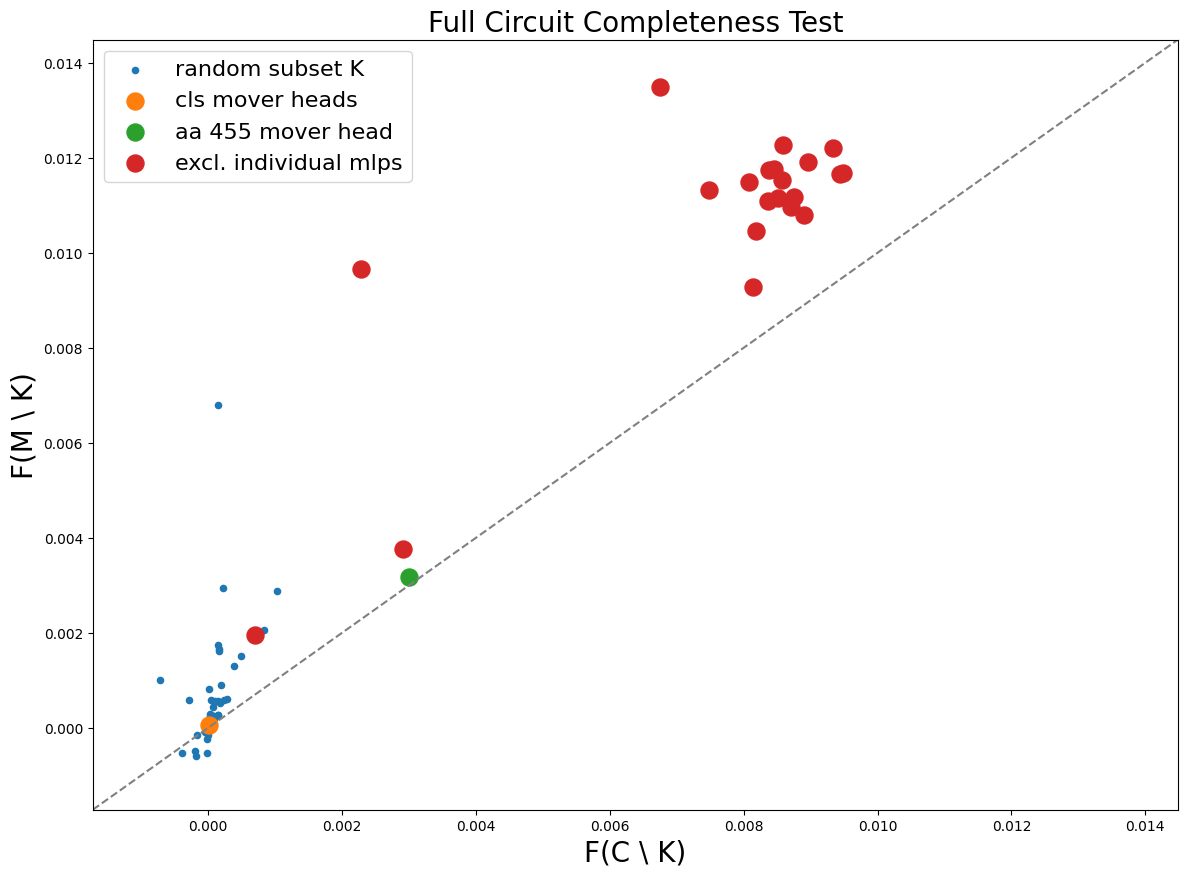

In [78]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.scatter(circ_diffs_num, true_diffs_num, label="random subset K", s=20)

ax.scatter([cls_mover_completeness[0][0].item()], [cls_mover_completeness[0][1].item()], label="cls mover heads", s=150)
ax.scatter([aa455_mover_completeness[0][0].item()], [aa455_mover_completeness[0][1].item()], label="aa 455 mover head", s=150)

# nm = 14
# ax.scatter([s[0] for s in indiv_mlp_completeness[nm:nm+1]], [s[1] for s in indiv_mlp_completeness[nm:nm+1]], label="excl. individual mlps", s=150)
ax.scatter([s[0].item() for s in indiv_mlp_completeness], [s[1].item() for s in indiv_mlp_completeness], label="excl. individual mlps", s=150)

ax.plot([mmin,mmax],[mmin, mmax], color="gray", linestyle="dashed")
ax.set_xlim([mmin, mmax])
ax.set_ylim([mmin, mmax])
ax.set_ylabel("F(M \\ K)", fontsize=20)
ax.set_xlabel("F(C \\ K)", fontsize=20)
ax.set_title("Full Circuit Completeness Test", fontsize=20)
plt.legend(fontsize=16)
plt.show()

# Minimality

### Let $\begin{cases} F(\cdot) \text{ denote model L/F-455 logit diff. when only including certain nodes (and mean-ablating others).} \\ C\text{ := circuit} \\ M \text{ := model}  \end{cases}$
### Then $\forall\,v\in C$, I want to find $K\subset C\,\textbackslash \{v\}$ s.t. $|F(C\,\textbackslash (K\cup \{v\}) - F(C\,\textbackslash K)|$ is large -- i.e. making sure that no irrelevant nodes have been included in circuit